# Ames Housing Sales Price Prediction

**link to dataset:** https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/overview

## Problem Definition

* **Objective:** Predict the sales price of houses in Ames, Iowa.

* **The Data:** We are working with a dataset containing detailed features and characteristics of various residential properties.

* **End Goal:** Develop a robust machine learning regression model and serve it via an API. In production, this API will accept a house's characteristics as input and return an estimated sales price.

## Columns Overview

The dataset contains 79 features that describe various aspects of residential homes in Ames, Iowa. The core objective is to predict the `SalePrice`. The features can be broadly categorized into the following groups:
### 🎯 Target Variable
*   **`SalePrice`**: The property's sale price in dollars. This is what we are trying to predict.
### 📐 Property Size & Space Features
These are often the strongest predictors of a home's value.
*   **`GrLivArea`**: Above grade (ground) living area square feet.
*   **`TotalBsmtSF`**: Total square feet of basement area.
*   **`1stFlrSF`** / **`2ndFlrSF`**: First and second-floor square feet.
*   **`LotArea`**: Lot size in square feet.
*   **`GarageArea`**: Size of garage in square feet.
*   **`GarageCars`**: Size of garage in car capacity.
### 🏆 Quality & Condition
Detailed assessments of the property's state.
*   **`OverallQual`**: Overall material and finish quality (rated 1 to 10).
*   **`OverallCond`**: Overall condition rating (rated 1 to 10).
*   **`ExterQual`** / **`ExterCond`**: Evaluates the quality/condition of the material on the exterior.
*   **`BsmtQual`** / **`BsmtCond`**: Evaluates the height/condition of the basement.
*   **`KitchenQual`**: Kitchen quality.
### 📍 Location & Neighborhood
Where the house is situated within Ames.
*   **`Neighborhood`**: Physical locations within Ames city limits.
*   **`Condition1`** / **`Condition2`**: Proximity to main roads or railroads.
*   **`MSZoning`**: The general zoning classification (e.g., Residential Low Density, Commercial).
### 🕰️ Age & Timeline
*   **`YearBuilt`**: Original construction date.
*   **`YearRemodAdd`**: Remodel date (same as construction date if no remodeling or additions).
*   **`GarageYrBlt`**: Year garage was built.
*   **`MoSold`** / **`YrSold`**: Month and year sold.
### 🛁 Rooms & Amenities
*   **`FullBath`** / **`HalfBath`**: Number of full and half bathrooms above grade.
*   **`BedroomAbvGr`**: Number of bedrooms above basement level.
*   **`TotRmsAbvGrd`**: Total rooms above grade (does not include bathrooms).
*   **`Fireplaces`**: Number of fireplaces.
*   **`CentralAir`**: Central air conditioning (Yes/No).
### 🔨 Exterior & Style Features
*   **`MSSubClass`**: The building class (e.g., 1-Story, 2-Story, Split-Level).
*   **`BldgType`**: Type of dwelling (e.g., Single-family, Townhouse).
*   **`HouseStyle`**: Style of dwelling (e.g., 1Story, 2Story, Split Foyer).
*   **`RoofStyle`** / **`RoofMatl`**: Type of roof and roofing material.
*   **`Exterior1st`** / **`Exterior2nd`**: Exterior covering on house.
### 🌳 Outdoor & Basement Details
*   **`BsmtFinSF1`** / **`BsmtFinSF2`**: Type 1 and Type 2 finished square feet in basement.
*   **`BsmtUnfSF`**: Unfinished square feet of basement area.
*   **`WoodDeckSF`**: Wood deck area in square feet.
*   **`OpenPorchSF`** / **`EnclosedPorch`**: Porch areas in square feet.
*   **`PoolArea`**: Pool area in square feet.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

#load dataset
train_df = pd.read_csv("../ml/data/raw/train.csv")
test_df = pd.read_csv("../ml/data/raw/test.csv")
#setup plot aesthetics
plt.style.use("seaborn-v0_8-whitegrid")

In [4]:
#take a look to the test dataset
train_df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [5]:
#take a look to the test dataset
test_df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal


In [6]:
# print only columns that have missing values and their types
null_count = train_df.isna().sum()
missing_columns = null_count[null_count > 0].sort_values(ascending=False)
missing_info = pd.DataFrame({
    "missing_Values":missing_columns,
    "Data_type":train_df[missing_columns.index].dtypes
})
missing_info

,missing_Values,Data_type
PoolQC,1453,object
MiscFeature,1406,object
Alley,1369,object
Fence,1179,object
MasVnrType,872,object
FireplaceQu,690,object
LotFrontage,259,float64
GarageType,81,object
GarageYrBlt,81,float64
GarageFinish,81,object


In [7]:
#print only columns that have missing values and their types (test dataset)
null_count = test_df.isna().sum()
missing_col = null_count[null_count > 0].sort_values(ascending=False)
missing_infos = pd.DataFrame({"missing_values":missing_col,"Data_type":test_df[missing_col.index].dtypes})
missing_infos

,missing_values,Data_type
PoolQC,1456,object
MiscFeature,1408,object
Alley,1352,object
Fence,1169,object
MasVnrType,894,object
FireplaceQu,730,object
LotFrontage,227,float64
GarageCond,78,object
GarageYrBlt,78,float64
GarageQual,78,object


## 1.understand the target Variable

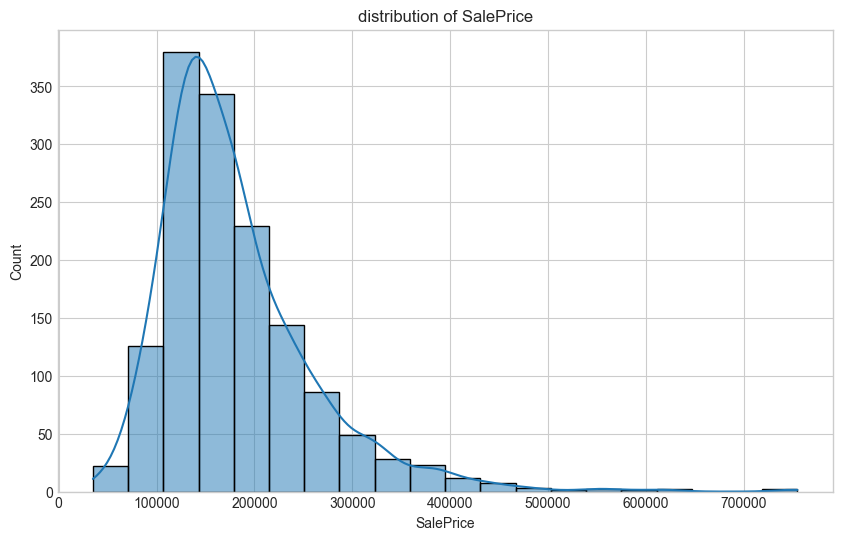

In [8]:
fig,ax = plt.subplots(figsize=(10,6))
sns.histplot(x=train_df["SalePrice"],kde=True,bins=20)
ax.set_title("distribution of SalePrice")
plt.show()

In [9]:
Mean = train_df["SalePrice"].mean()
Median = train_df["SalePrice"].median()
print({"Mean":Mean,"Median":Median})

{'Mean': np.float64(180921.19589041095), 'Median': np.float64(163000.0)}


**Notes**

we can see that the distribution is **right skewed** we have:

Mean = **180921$**
Median = **163000$**

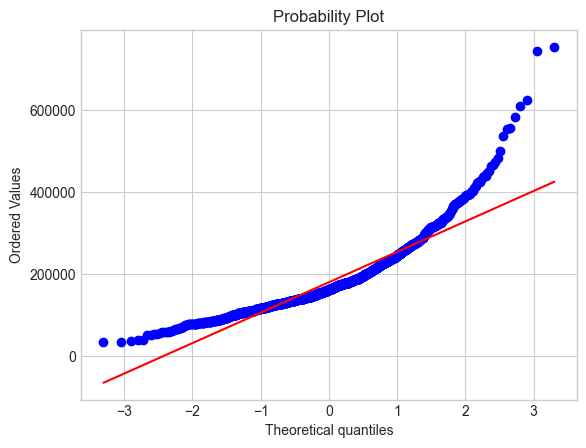

In [10]:
stats.probplot(train_df["SalePrice"],dist="norm",plot=plt)
plt.show()

**Q–Q Plot Interpretation**

The `Q–Q plot` indicates that the data does not follow a normal distribution, 
as the points clearly deviate from the diagonal line.

Combined with the previous histogram showing right skewness, 
this suggests that a transformation is needed to normalize the distribution.

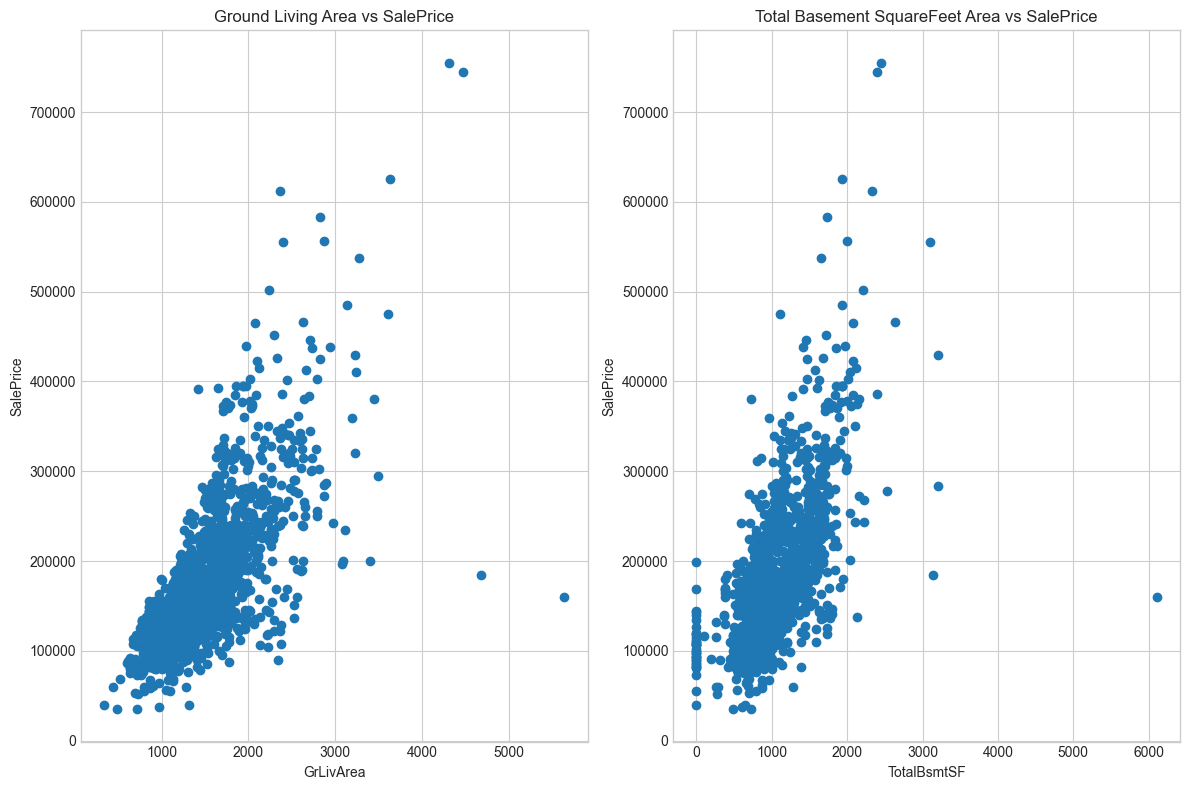

In [11]:
fig,axes = plt.subplots(1,2,figsize=(12,8))
axes[0].scatter(x=train_df["GrLivArea"],y=train_df["SalePrice"])
axes[0].set_xlabel("GrLivArea")
axes[0].set_ylabel("SalePrice")
axes[1].scatter(x=train_df["TotalBsmtSF"],y=train_df["SalePrice"])
axes[1].set_xlabel("TotalBsmtSF")
axes[1].set_ylabel("SalePrice")
axes[0].set_title("Ground Living Area vs SalePrice")
axes[1].set_title("Total Basement SquareFeet Area vs SalePrice")
plt.tight_layout()
plt.show()

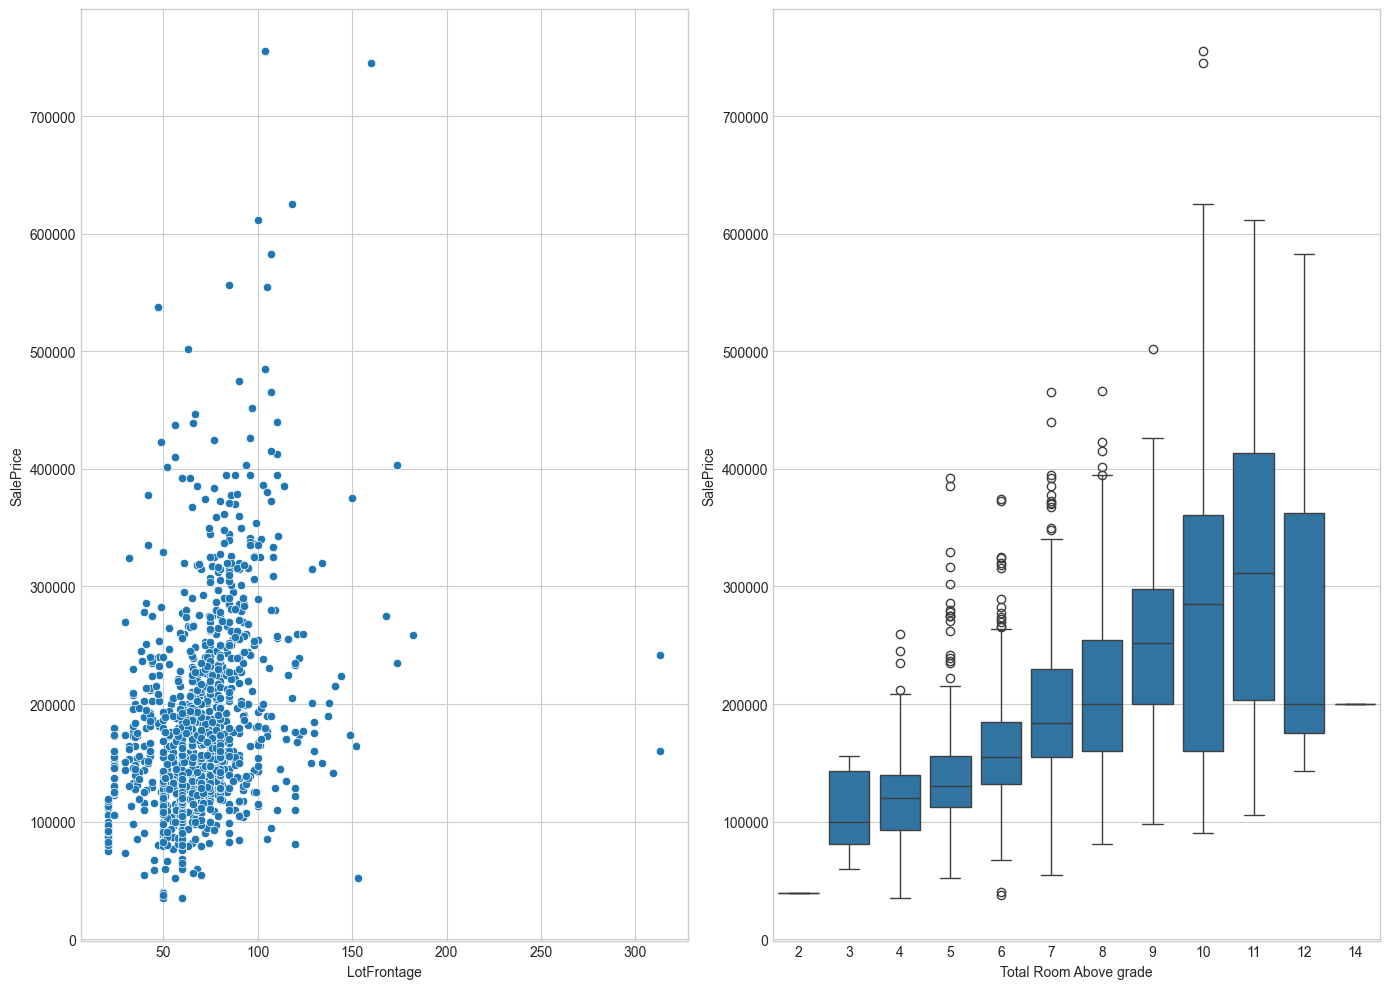

In [12]:
fig,axes = plt.subplots(1,2,figsize=(14,10))
axes[0].set_xlabel("LotFrontage")
axes[0].set_ylabel("SalePrice")
sns.scatterplot(x=train_df["LotFrontage"],y=train_df["SalePrice"],ax=axes[0])
axes[1].set_xlabel("Total Room Above grade")
axes[1].set_ylabel("SalePrice")
sns.boxplot(x=train_df["TotRmsAbvGrd"],y=train_df["SalePrice"],ax=axes[1])
plt.tight_layout()
plt.show()

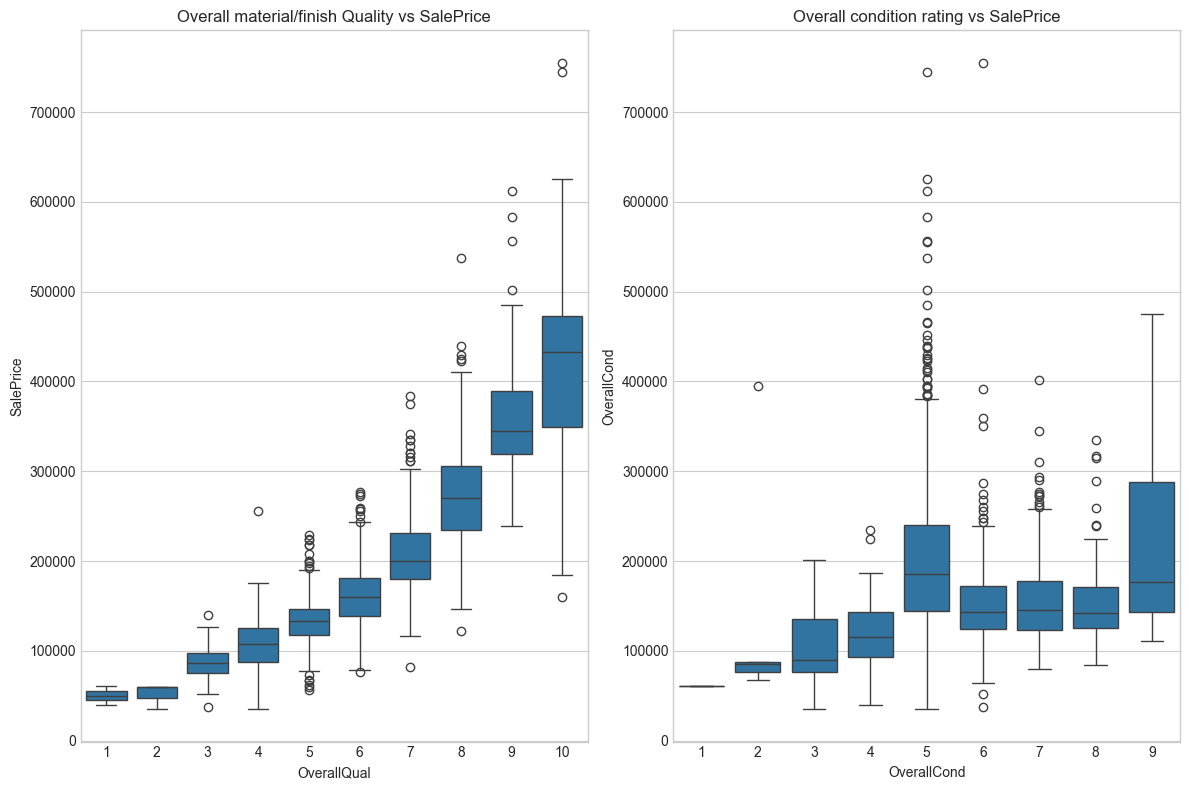

In [13]:
fig,axes = plt.subplots(1,2,figsize=(12,8))
sns.boxplot(x=train_df["OverallQual"],y=train_df["SalePrice"],ax=axes[0])
axes[0].set_xlabel("OverallQual")
axes[0].set_ylabel("SalePrice")
sns.boxplot(x=train_df["OverallCond"],y=train_df["SalePrice"],ax=axes[1])
axes[1].set_xlabel("OverallCond")
axes[1].set_ylabel("OverallCond")
axes[0].set_title("Overall material/finish Quality vs SalePrice")
axes[1].set_title("Overall condition rating vs SalePrice")
plt.tight_layout()
plt.show()

**Observation**

`OverallQual` shows a strong positive correlation with `SalePrice`.  
Higher construction and finish quality is associated with higher house prices.

## Correlation Matrix 

In [14]:
corr_target = train_df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)[:15]
top_features = corr_target.index
corr_matrix = train_df[top_features].corr()
corr_target

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

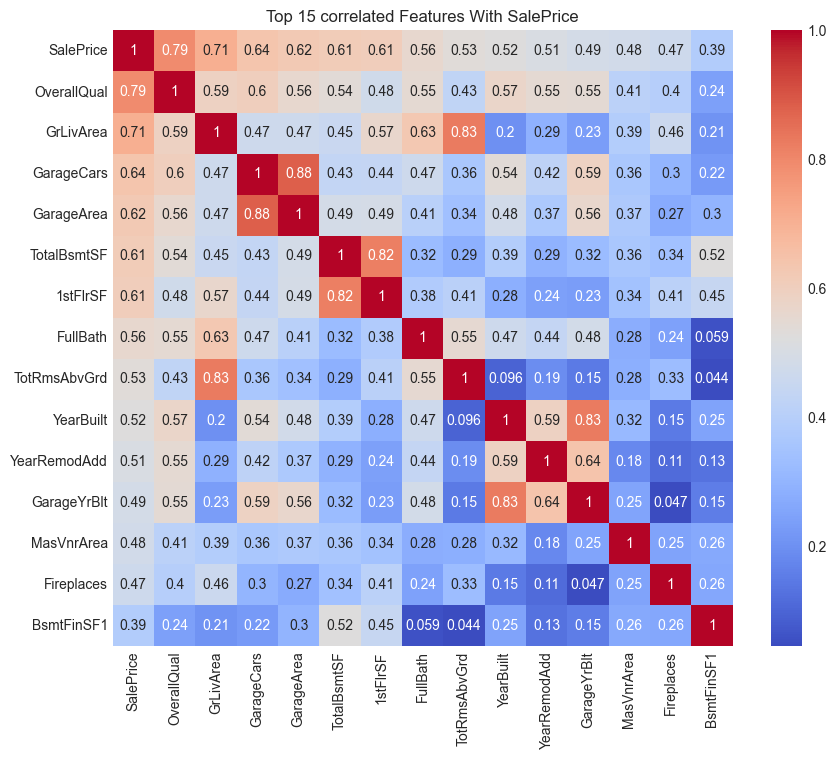

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm")
plt.title("Top 15 correlated Features With SalePrice")
plt.show()

**Correlation Analysis**

1. The following features show a strong positive correlation with `SalePrice`:  
   `OverallQual`, `GrLivArea`, `GarageCars`, `GarageArea`, `TotalBsmtSF`, and `1stFlrSF`.  
   This suggests that larger living areas, better overall quality, and garage capacity 
   are important drivers of house prices.

2. We also observe a strong correlation between `GarageCars` and `GarageArea`, 
   indicating potential multicollinearity. Since both variables describe similar 
   information (garage size/capacity).

## Handling Missing Data

In [16]:
cols_none = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 
             'BsmtFinType2', 'MasVnrType']
for col in cols_none:
    train_df[col] = train_df[col].fillna("missing")

cols_zero = ['GarageYrBlt', 'GarageArea', 'GarageCars', 
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF','TotalBsmtSF', 
             'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']
for col in cols_zero:
    train_df[col] = train_df[col].fillna(0)

cols_mode = ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st', 
             'Exterior2nd', 'SaleType']

for col in cols_mode:
    train_df[col] = train_df[col].fillna(train_df[col].mode()[0])

train_df["LotFrontage"] = train_df.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median()))
train_df.isna().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64

In [17]:
#remove outliers
outlier_condition = train_df["LotFrontage"] > 300
train_df = train_df.drop(train_df[outlier_condition].index)
outlier_condition2 = train_df["GrLivArea"] > 4000
train_df = train_df.drop(train_df[outlier_condition2].index)

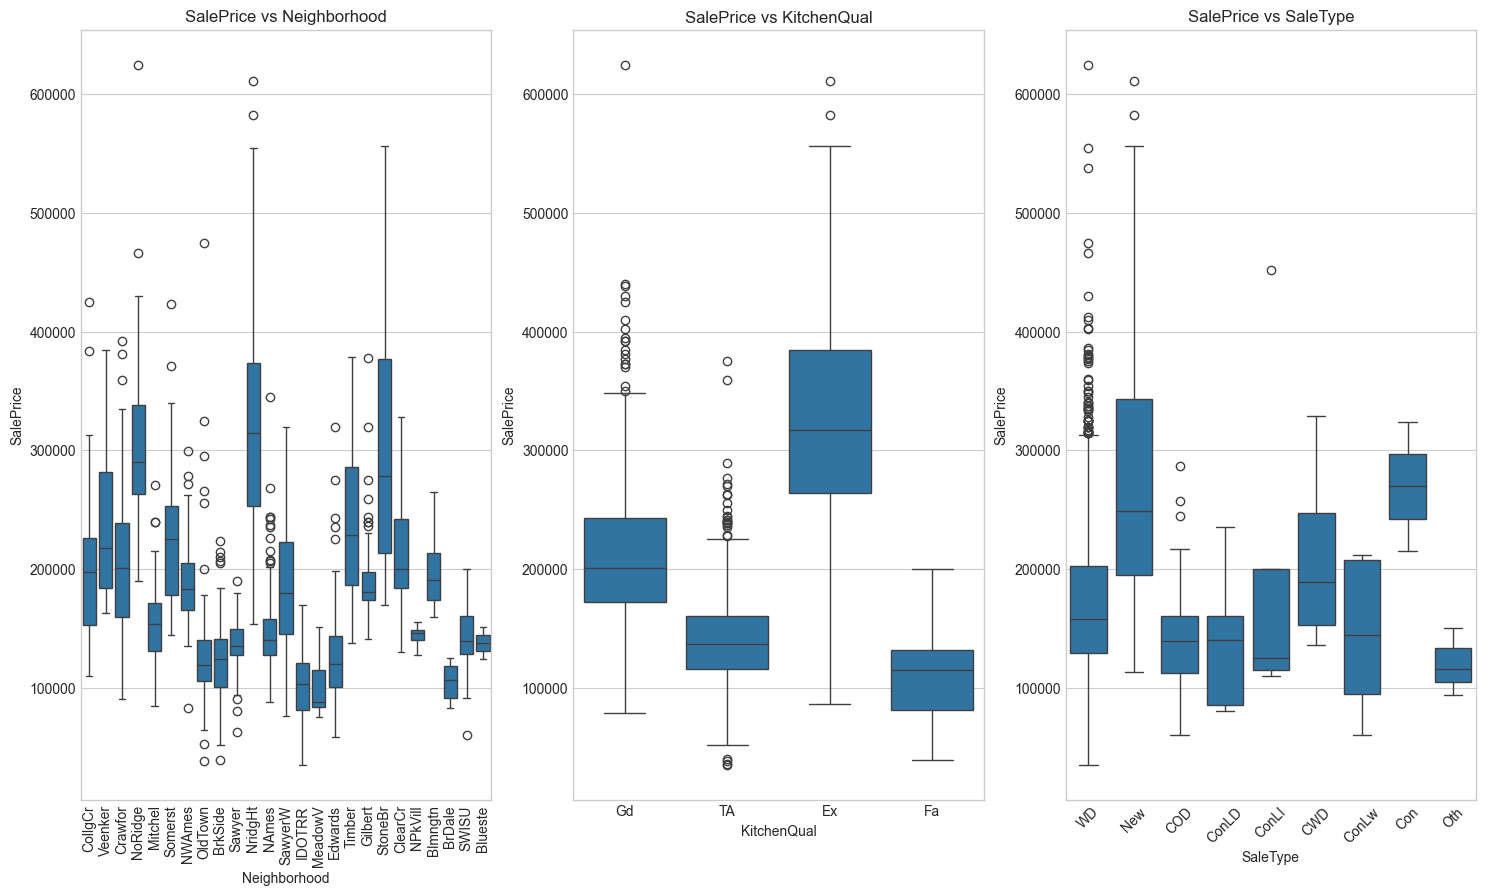

In [18]:
fig,axes = plt.subplots(1,3,figsize=(18,10))
#BoxPlot for Neighborhood
sns.boxplot(x=train_df["Neighborhood"],y=train_df["SalePrice"],ax=axes[0])
axes[0].set_title("SalePrice vs Neighborhood")
axes[0].tick_params(axis="x",rotation=90)

#BoxPlot for Kitchen Quality
sns.boxplot(x=train_df["KitchenQual"],y=train_df["SalePrice"],ax=axes[1])
axes[1].set_title("SalePrice vs KitchenQual")

#BoxPlot for SaleType
sns.boxplot(x=train_df["SaleType"],y=train_df["SalePrice"],ax=axes[2])
axes[2].set_title("SalePrice vs SaleType")
axes[2].tick_params(axis="x",rotation=45)


**Notes**

1-we can see that some neighborhoods like : `NoRidge`,`NrifgHt` have impacts on price rise.

2- we can see also that Kitchen Quality matters on SalePrice


## Feature Engineering

In [19]:
#create a new column Total Square Footage
train_df["TotalSF"] = train_df["TotalBsmtSF"]+train_df["1stFlrSF"]+train_df["2ndFlrSF"]
test_df["TotalSF"] = test_df["TotalBsmtSF"]+test_df["1stFlrSF"]+test_df["2ndFlrSF"]

#create HouseAge and YearsSinceRemodel
train_df["HouseAge"] = train_df["YrSold"]-train_df["YearBuilt"]
test_df["HouseAge"] = test_df["YrSold"]-test_df["YearBuilt"]

train_df["YearsSinceRemodel"] = train_df["YrSold"] - train_df["YearRemodAdd"]
test_df["YearsSinceRemodel"] = test_df["YrSold"] - test_df["YearRemodAdd"]

#drop GarageArea since we have GarageCars and they are the same (avoid multicolinearity)
train_df.drop(columns=["GarageArea","1stFlrSF","2ndFlrSF","YearBuilt","YrSold","YearRemodAdd"],inplace=True)
test_df.drop(columns=["GarageArea","1stFlrSF","2ndFlrSF","YearBuilt","YrSold","YearRemodAdd"],inplace=True)

#apply log transformation for SalePrice to minimize Skeweness:
train_df["Log_SalePrice"] = np.log1p(train_df["SalePrice"])

## Visualize Transformation

Text(0.5, 1.0, 'SalePrice and Normal Distribution')

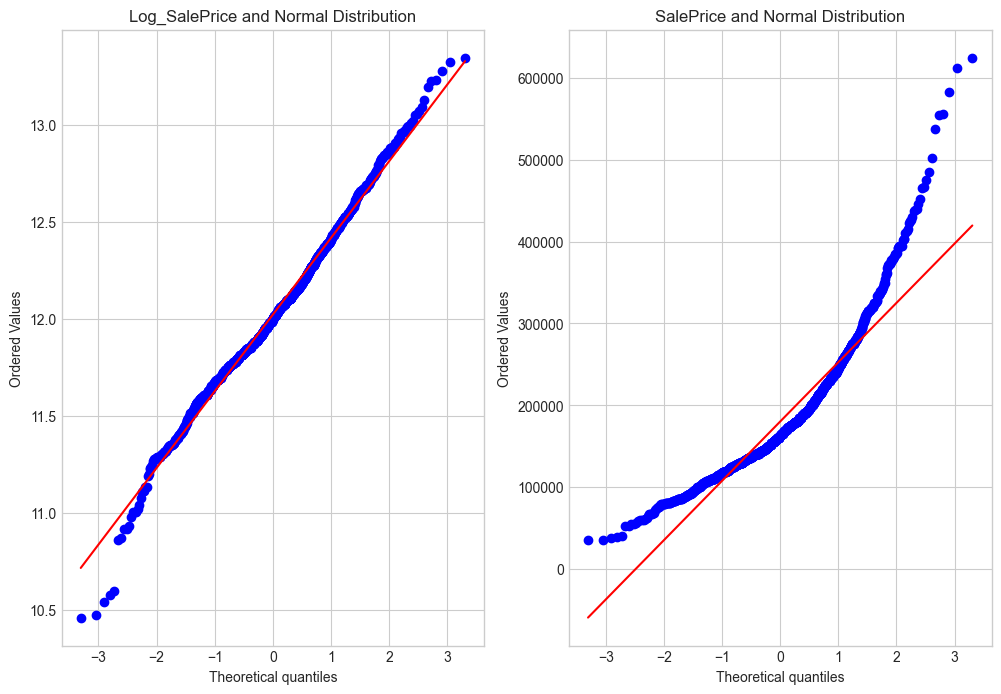

In [20]:
fig,axes = plt.subplots(1,2,figsize=(12,8))
stats.probplot(train_df["Log_SalePrice"],plot=axes[0],dist="norm")
axes[0].set_title("Log_SalePrice and Normal Distribution")
stats.probplot(train_df["SalePrice"],plot=axes[1],dist="norm")
axes[1].set_title("SalePrice and Normal Distribution")

Text(0.5, 1.0, 'TotalBsmtSF vs Log_SalePrice')

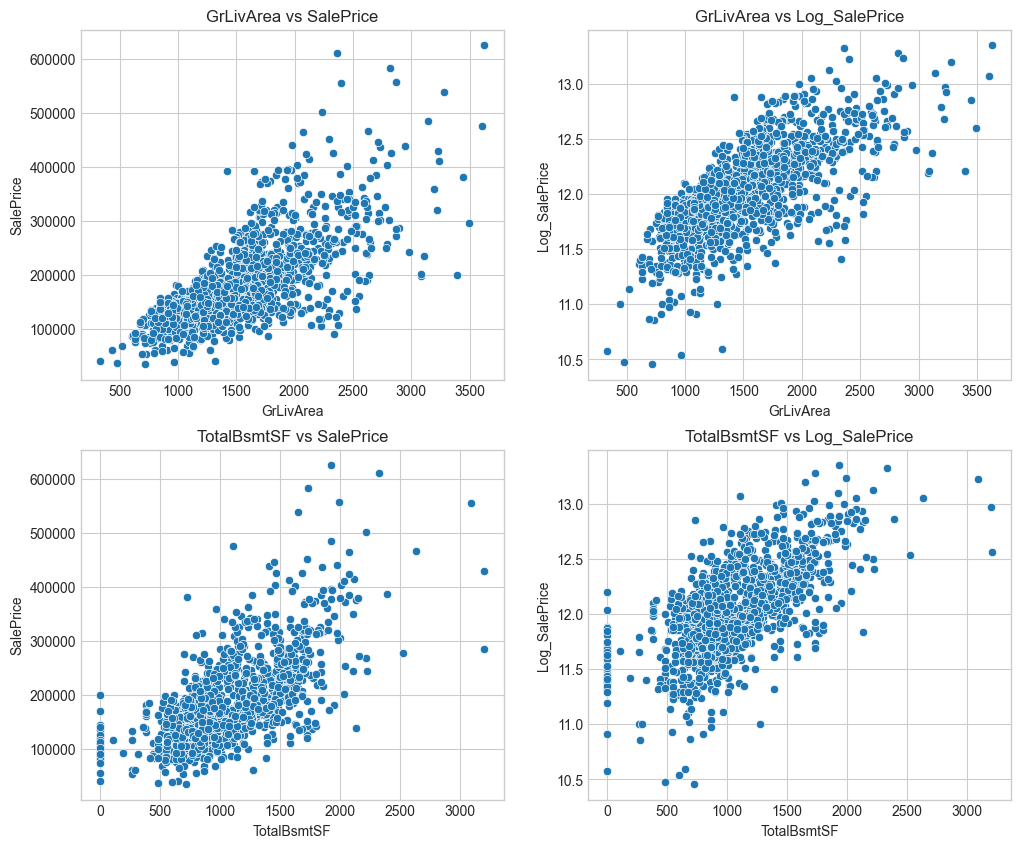

In [21]:
fig,axes = plt.subplots(2,2,figsize=(12,10))
sns.scatterplot(x=train_df["GrLivArea"],y=train_df["SalePrice"],ax=axes[0,0])
sns.scatterplot(x=train_df["GrLivArea"],y=train_df["Log_SalePrice"],ax=axes[0,1])
axes[0,0].set_title("GrLivArea vs SalePrice")
axes[0,1].set_title("GrLivArea vs Log_SalePrice")

sns.scatterplot(x=train_df["TotalBsmtSF"],y=train_df["SalePrice"],ax=axes[1,0])
sns.scatterplot(x=train_df["TotalBsmtSF"],y=train_df["Log_SalePrice"],ax=axes[1,1])
axes[1,0].set_title("TotalBsmtSF vs SalePrice")
axes[1,1].set_title("TotalBsmtSF vs Log_SalePrice")


## Baseline Model (Linear Regression)

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler

X = train_df.drop(columns=["SalePrice","Log_SalePrice"])
y = train_df["Log_SalePrice"]

categorical_columns = X.select_dtypes(include="object").columns
numerical_columns = X.select_dtypes(exclude="object").columns

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

categorical_transformer = Pipeline(steps=[
            ("one_hot",OneHotEncoder(handle_unknown="ignore")),
    ])
numerical_transformer = Pipeline(steps=[
        ("scaler",StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat_transformer",categorical_transformer,categorical_columns),
        ("num_transformer",numerical_transformer,numerical_columns)
        ]
)

baseline_model = Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("model",LinearRegression())
])



In [23]:
from sklearn.metrics import r2_score,mean_squared_error
baseline_model.fit(X_train,y_train)
y_preds = baseline_model.predict(X_test)
accuracy_score = r2_score(y_test,y_preds)
mse = mean_squared_error(y_test,y_preds)
print({"accuracy":accuracy_score,"MSE":mean_squared_error})

{'accuracy': 0.9018670634437908, 'MSE': <function mean_squared_error at 0x14d9013a0>}


## Visualize The Regression Line

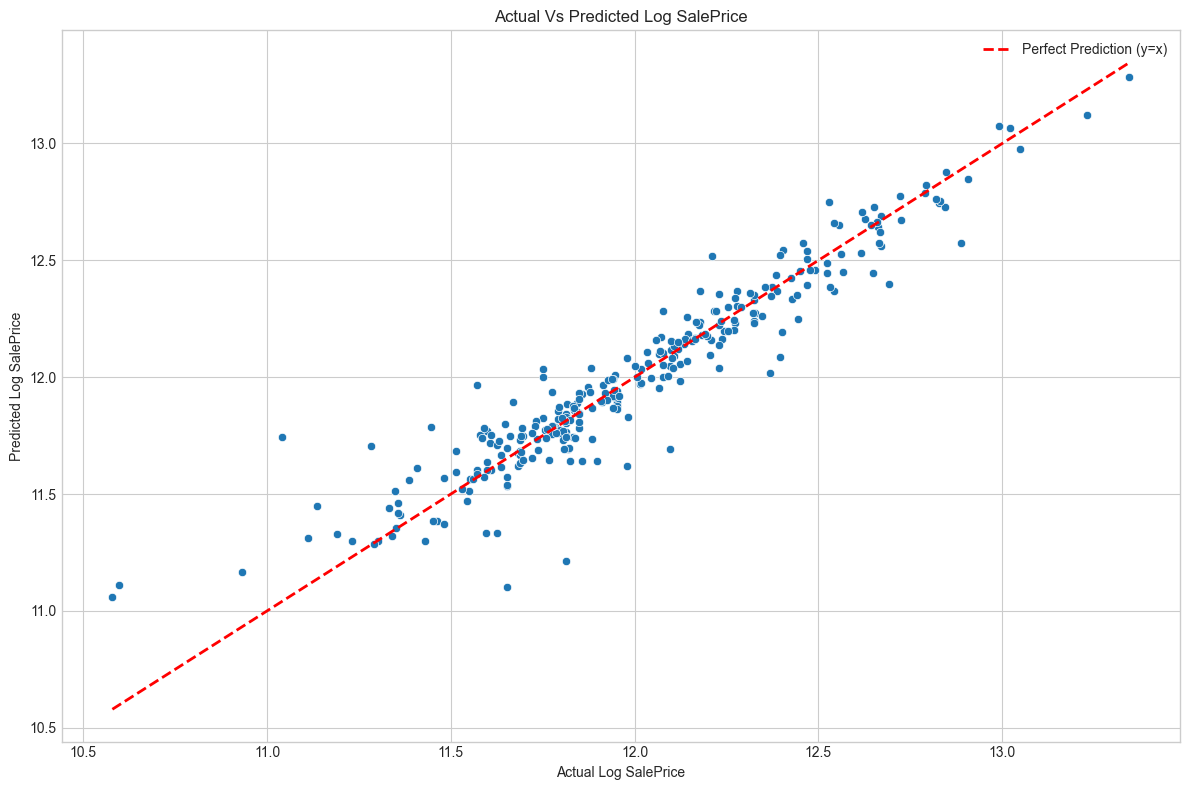

In [24]:
fig,ax = plt.subplots(figsize=(12,8))
sns.scatterplot(x=y_test,y=y_preds,ax=ax)
min_val = min(y_test.min(),y_preds.min())
max_val = max(y_test.max(),y_preds.max())
plt.plot([min_val,max_val],[min_val,max_val],color="red",linestyle="--",linewidth=2,label="Perfect Prediction (y=x)")
plt.title(f'Actual Vs Predicted Log SalePrice')
plt.xlabel("Actual Log SalePrice")
plt.ylabel("Predicted Log SalePrice")
plt.legend()
plt.tight_layout()
plt.show()

## Ridge Regression

In [25]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge_pipeline = Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("model",Ridge())
])

param_grid = {
    "model__alpha":[0.1,1.0,10.0,50.0,100.0,200.0]
}

grid_search = GridSearchCV(estimator=ridge_pipeline,param_grid=param_grid,cv=5,scoring="neg_root_mean_squared_error",n_jobs=-1)
grid_search.fit(X_train,y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.1, 1.0, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3

In [26]:
best_ridge_model = grid_search.best_estimator_
y_ridge_preds = best_ridge_model.predict(X_test)
r_MSE = mean_squared_error(y_test,y_ridge_preds)
r2_score_ridge = r2_score(y_test,y_ridge_preds)
print({"R^2":r2_score_ridge,"mean_square_error":r_MSE})

{'R^2': 0.9139405035175935, 'mean_square_error': 0.015801048018558143}


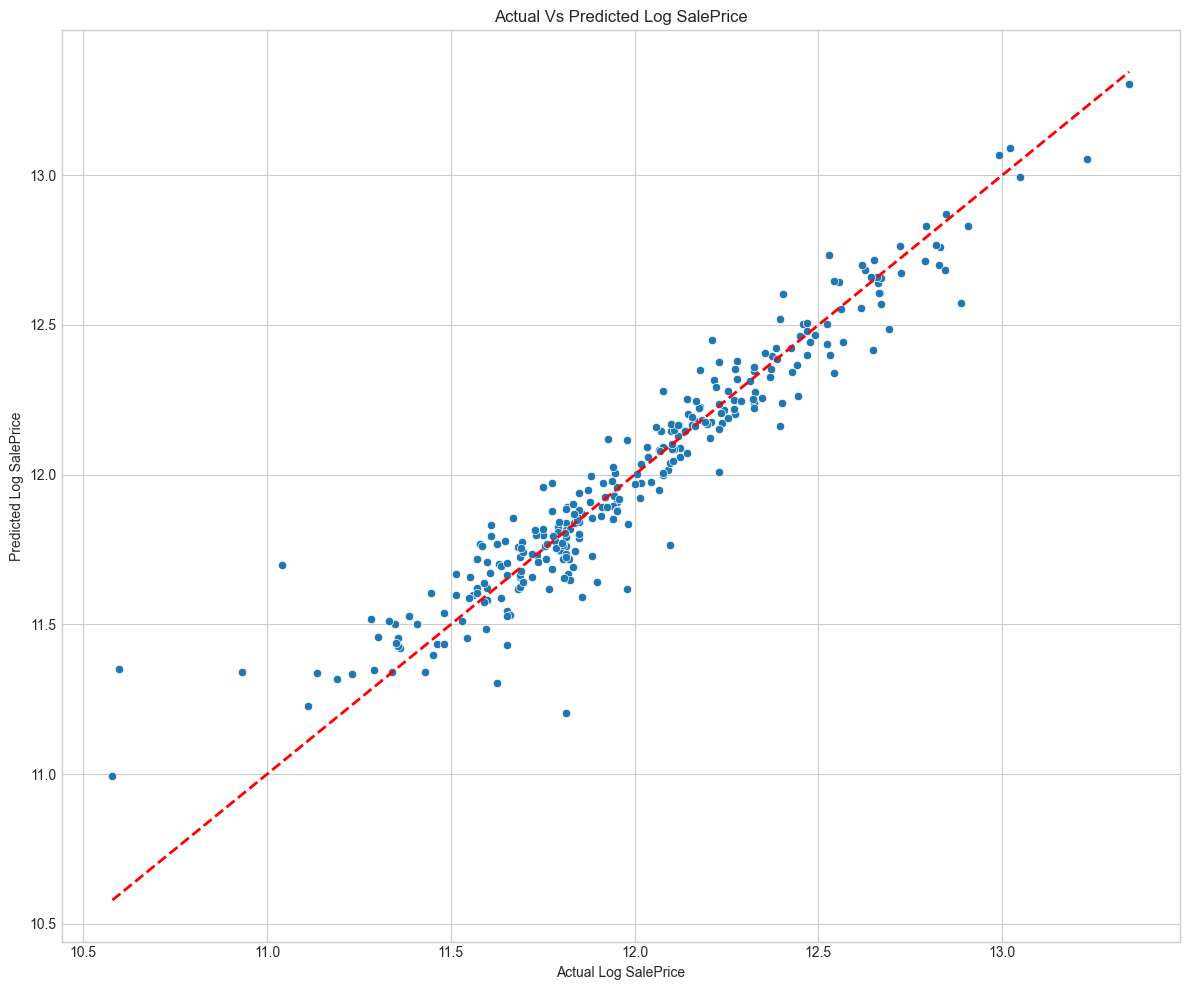

In [27]:
fig,ax = plt.subplots(figsize=(12,10))
min_y = min(y_test.min(),y_ridge_preds.min())
max_y = max(y_test.max(),y_ridge_preds.max())
sns.scatterplot(x=y_test,y=y_ridge_preds,ax=ax)
plt.plot([min_y,max_y],[min_y,max_y],color="red",linestyle="--",linewidth=2,label="Perfect Prediction (y=x)")
ax.set_xlabel("Actual Log SalePrice")
ax.set_ylabel("Predicted Log SalePrice")
ax.set_title("Actual Vs Predicted Log SalePrice")
plt.tight_layout()
plt.show()

# Random Forest

In [87]:
from altair import value
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score,mean_squared_error
import sys
sys.path.insert(0,'..')
from ml.features.preprocessing import housing_preprocessor

X = train_df.drop(columns=["Log_SalePrice","SalePrice"])
y = train_df["Log_SalePrice"]
X_engineered = housing_preprocessor.fit_transform(X)


categorical_columns = X_engineered.select_dtypes(include="object").columns
numerical_columns = X_engineered.select_dtypes(exclude="object").columns

categorical_transformer = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="constant",fill_value="missing")),
    ("cat",OneHotEncoder(handle_unknown="ignore"))
    
])

numerical_transformer = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="median")),
    ("num",StandardScaler())
    
])

preprocessor = ColumnTransformer(transformers=[
    ("cat_transformer",categorical_transformer,categorical_columns),
    ("num_transformer",numerical_transformer,numerical_columns)
    ])

pipeline = Pipeline(steps=[
    ("feature",housing_preprocessor),
    ("preprocessor",preprocessor),
    ("model",RandomForestRegressor(random_state=42))
])


In [88]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)
pipeline.fit(X_train,y_train)
y_preds = pipeline.predict(X_test)
print(f"r2_score: {r2_score(y_test,y_preds)} / mse: {mean_squared_error(y_test,y_preds)} ")

r2_score: 0.8892566574223085 / mse: 0.01593480443110252 


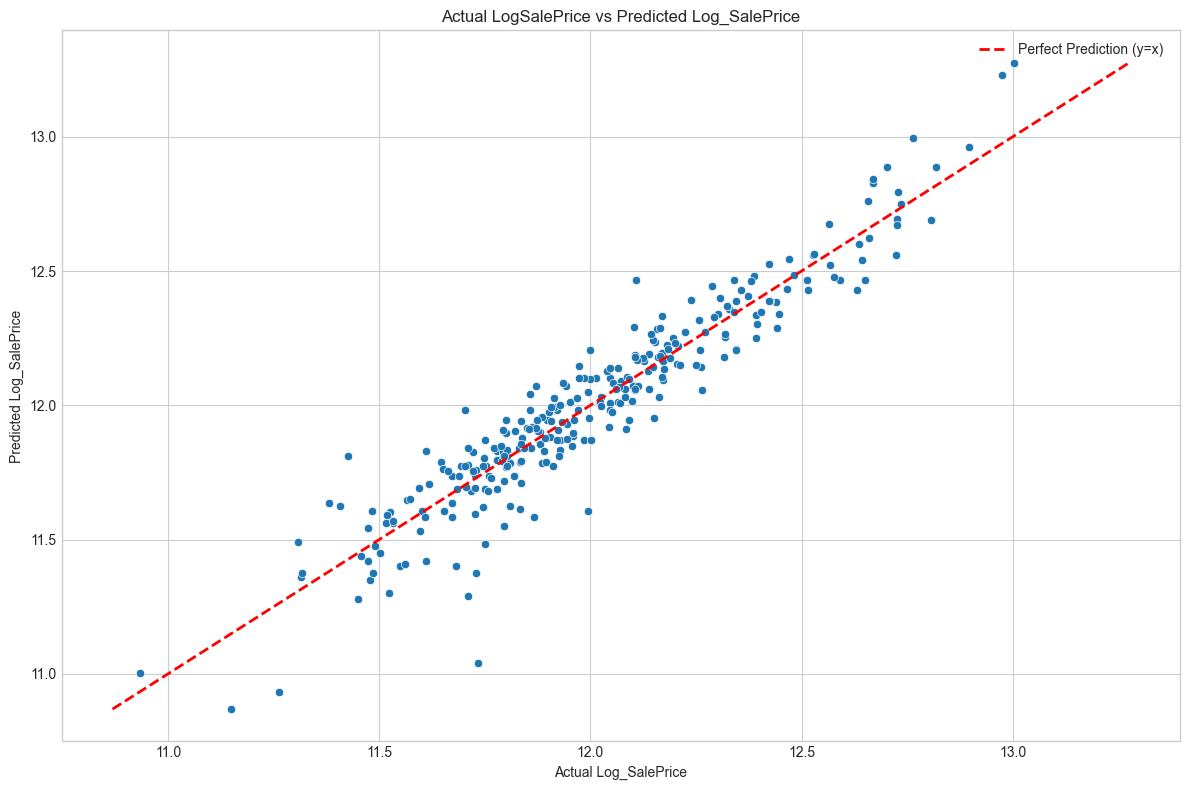

In [55]:
fig,ax = plt.subplots(figsize=(12,8))
sns.scatterplot(x=y_preds,y=y_test,ax=ax)
min_y = min(y_test.min(),y_preds.min())
max_y = max(y_test.max(),y_preds.max())
plt.plot([min_y,max_y],[min_y,max_y],color="red",linestyle="--",linewidth=2,label="Perfect Prediction (y=x) ")
ax.set_xlabel("Actual Log_SalePrice")
ax.set_ylabel("Predicted Log_SalePrice")
ax.set_title("Actual LogSalePrice vs Predicted Log_SalePrice")
plt.legend()
plt.tight_layout()
plt.show()

# XGBOOST

### 1. fit the model using **baseline xgboost**


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from ml.features.preprocessing import housing_preprocessor

X = train_df.drop(columns=["SalePrice","Log_SalePrice"])
y = train_df["Log_SalePrice"]

X_engineered = housing_preprocessor.fit_transform(X)
categorical_columns = X_engineered.select_dtypes(include="object").columns
numerical_columns = X_engineered.select_dtypes(exclude="object").columns

categorical_transformer = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="constant",fill_value="missing")),
    ("cat",OneHotEncoder(handle_unknown="ignore"))
])

numerical_transformer = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="median")),
    ("num",StandardScaler())
    
])

preprocessor = ColumnTransformer(transformers=[
    ("cat_transformer",categorical_transformer,categorical_columns),
    ("num_transformer",numerical_transformer,numerical_columns)
    ])

pipeline = Pipeline(steps=[
    ("feature",housing_preprocessor),
    ("preprocessor",preprocessor),
    ("model",XGBRegressor())
])


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)
pipeline.fit(X_train,y_train)
y_preds = pipeline.predict(X_test)
print(f"mean_squared_error: {mean_squared_error(y_test,y_preds)} / r2_score : {r2_score(y_test,y_preds)} / neg_mean_squared_score: {neg_mean_squared_error(y_test,y_preds)}")

mean_squared_error: 0.0162620510580512 / r2_score : 0.908208480642687


### 2.fit the model using XGboost with Hyperparameter tuning


In [79]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators":[50,100,200],
    "model__learning_rate":[0.01,0.1],
    "model__max_depth":[3,7],
    "model__subsample":[0.8,1.0],
    "model__colsample_bytree":[0.8,1.0],
    "model__gamma":[0,0.1]
}

grid_search = GridSearchCV(estimator=pipeline,param_grid=param_grid,scoring="neg_mean_squared_error",cv=5,verbose=1)
grid_search.fit(X_train,y_train)

Fitting 5 folds for each of 96 candidates, totalling 480 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__colsample_bytree': [0.8, 1.0], 'model__gamma': [0, 0.1], 'model__learning_rate': [0.01, 0.1], 'model__max_depth': [3, 7], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computat

In [81]:
grid_search.best_score_

np.float64(-0.014659107175357965)

In [86]:
best_model = grid_search.best_estimator_
y_preds_xgb = best_model.predict(X_test)
print(f"R2: {r2_score(y_test,y_preds)}")

R2: 0.8718108034044079


In [ ]:
fig,ax = plt.subplots(figsize=(12,8))
sns.scatterplot(x=y_preds,y=y_test,ax=ax)
min_y = min(y_test.min(),y_preds.min())
max_y = max(y_test.max(),y_preds.max())
plt.plot([min_y,max_y],[min_y,max_y],color="red",linestyle="--",linewidth=2,label="Perfect Prediction (y=x) ")
ax.set_xlabel("Actual Log_SalePrice")
ax.set_ylabel("Predicted Log_SalePrice")
ax.set_title("Actual LogSalePrice vs Predicted Log_SalePrice")
plt.legend()
plt.tight_layout()
plt.show()